# OHCA Events per County: Spatial Autocorrelation in Google Colab

This notebook uses the OHCA training dataset and U.S. county boundaries to:

1. Convert OHCA records with latitude/longitude into spatial points.
2. Spatially join points to county polygons.
3. Count OHCA events per county.
4. Run Global Moran's I and Local Moran's I / LISA.
5. Map event counts and statistically significant clusters.

**Note:** Moran's I requires a variable, not just coordinates. Here the variable is `ohca_event_count`, the number of OHCA events in each county.

## 1. Install Packages

Run this cell in Google Colab. It installs the geospatial and spatial-statistics libraries used in the workshop.

In [1]:
# Install geospatial statistics libraries required for Moran's I and LISA.
!pip -q install geopandas libpysal esda mapclassify matplotlib folium

In [4]:
# Mount Google Drive so the notebook can read and write workshop files.
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


## 2. Import Libraries and Set File Paths

For Colab, upload the `data` folder or mount Google Drive and update `DATA_DIR` if needed. The shapefile must keep all sidecar files together: `.shp`, `.shx`, `.dbf`, `.prj`, and `.cpg`.

In [5]:
# Use pathlib for cleaner notebook path definitions.
from pathlib import Path

# Import the libraries used in the analysis.
import numpy as np
# Import the libraries used in the analysis.
import pandas as pd
# Import the libraries used in the analysis.
import geopandas as gpd
# Import the libraries used in the analysis.
import matplotlib.pyplot as plt

# Import the required helper from its package.
from libpysal.weights import Queen, KNN, lag_spatial
# Import the required helper from its package.
from esda.moran import Moran, Moran_Local

# Use either local or Colab path to load data.
# Local path
LOCAL_DATA_DIR = Path('/Users/jenny/Desktop/Using-Python-for-Geospatial-Analysis-and-Visualization-main/data')
# Colab path
COLAB_DATA_DIR = Path('/content/drive/MyDrive/Colab Notebooks/Using-Python-for-Geospatial-Analysis-and-Visualization-main/data')
# If Colab path exists, use it; otherwise use local path.
DATA_DIR = COLAB_DATA_DIR if COLAB_DATA_DIR.exists() else LOCAL_DATA_DIR

# Define the full path to the OHCA CSV file.
OHCA_CSV = DATA_DIR/'ohca_connected_data.csv'
# Define the full path to the county shapefile.
COUNTY_SHP = DATA_DIR/'cb_2018_us_county_500k'/'cb_2018_us_county_500k - Copy.shp'

# Print paths
print('OHCA file:', OHCA_CSV)
print('County shapefile:', COUNTY_SHP)

OHCA file: /content/drive/MyDrive/Colab Notebooks/Using-Python-for-Geospatial-Analysis-and-Visualization-main/data/ohca_connected_data.csv
County shapefile: /content/drive/MyDrive/Colab Notebooks/Using-Python-for-Geospatial-Analysis-and-Visualization-main/data/cb_2018_us_county_500k/cb_2018_us_county_500k - Copy.shp


## 3. Load OHCA Records and Create Point Geometry

The OHCA file has latitude and longitude columns. We convert the table into a `GeoDataFrame` using WGS84 coordinates (`EPSG:4326`).

In [6]:
# define the latitude and longitude columns
lat_col = 'scene_gps_latitude_escene.11'
lon_col = 'scene_gps_longitude_escene.11'

# Read the CSV data into a pandas DataFrame.
ohca = pd.read_csv(OHCA_CSV)
# Convert this column to numeric values and mark invalid entries as missing.
ohca[lat_col] = pd.to_numeric(ohca[lat_col], errors='coerce')
# Convert this column to numeric values and mark invalid entries as missing.
ohca[lon_col] = pd.to_numeric(ohca[lon_col], errors='coerce')
# Drop records with missing values required for this analysis.
ohca = ohca.dropna(subset=[lat_col, lon_col]).copy()

# Create OHCA point geometries from longitude and latitude coordinates.
ohca_points = gpd.GeoDataFrame(
    ohca,
    geometry=gpd.points_from_xy(ohca[lon_col], ohca[lat_col]),
    crs='EPSG:4326'
)

# Print this value to check the result.
print('OHCA records with valid coordinates:', len(ohca_points))
# Preview the first rows of the result.
ohca_points[[lat_col, lon_col, 'incident_date']].head()

OHCA records with valid coordinates: 6005


,scene_gps_latitude_escene.11,scene_gps_longitude_escene.11,incident_date
0,33.720626,-84.233276,2020-05-16
1,34.853186,-84.343906,2021-07-29
2,32.108308,-81.551837,2020-10-26
3,33.716513,-84.317138,2019-11-24
4,33.942115,-83.413094,2021-12-22


## 4. Quick Map of OHCA Point Locations

Before joining the points to county polygons, it is useful to plot the point layer by itself. This helps confirm that the coordinates are in the expected study area and that latitude/longitude were assigned correctly.

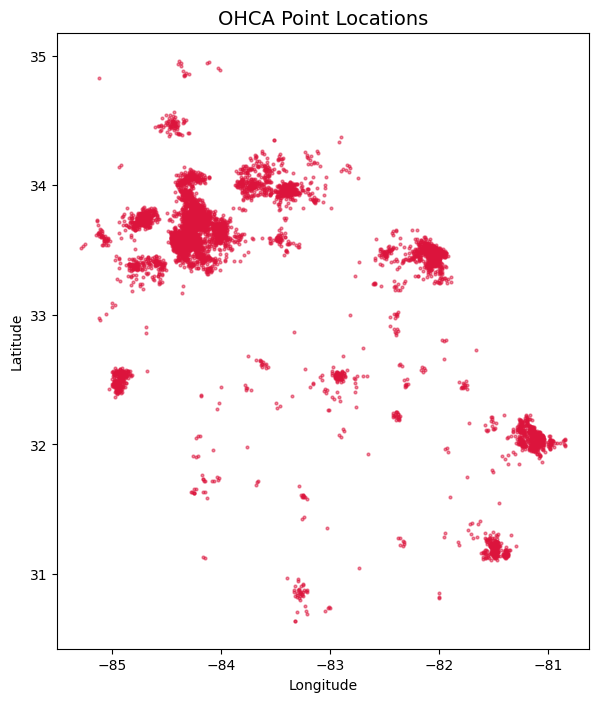

In [7]:
# Create an initial map to inspect OHCA event distribution.
fig, ax = plt.subplots(figsize=(8, 8))
# Draw the map or chart for this analysis output.
ohca_points.plot(
    ax=ax,
    markersize=4,
    alpha=0.5,
    color='crimson'
)
# Adjust the plot appearance.
ax.set_title('OHCA Point Locations', fontsize=14)
# Label the x-axis with longitude values.
ax.set_xlabel('Longitude')
# Label the y-axis with latitude values.
ax.set_ylabel('Latitude')
# Show the completed plot.
plt.show()

## 5. Load Georgia County Boundaries and Overlay OHCA Points

Load U.S. county polygons, filter to **Georgia** (`STATEFP = '13'`), and overlay OHCA points on the county map so participants can visually verify both layers before spatial join.

Georgia counties: 159


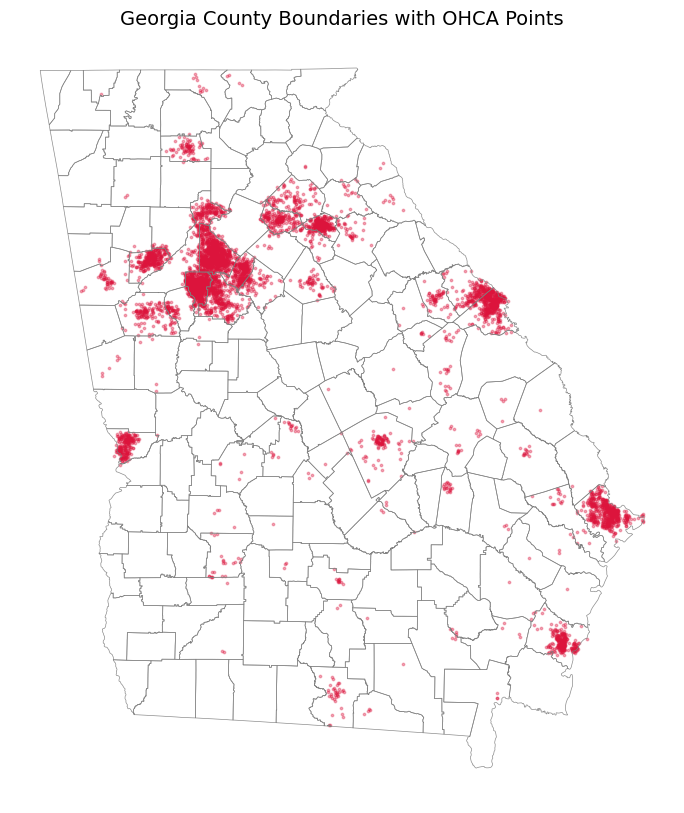

,GEOID,NAME,geometry
70,13009,Baldwin,"POLYGON ((-83.42674 33.18273, -83.42496 33.182..."
71,13027,Brooks,"MULTIPOLYGON (((-83.33829 30.63972, -83.33708 ..."
72,13103,Effingham,"POLYGON ((-81.54801 32.48929, -81.5455 32.4938..."
73,13121,Fulton,"POLYGON ((-84.84931 33.51318, -84.84429 33.514..."
74,13141,Hancock,"POLYGON ((-83.27522 33.19132, -83.27413 33.196..."


In [8]:
# Load Georgia counties and align CRS for spatial joins and mapping.
county = gpd.read_file(COUNTY_SHP).to_crs('EPSG:4326')

# Identify the county GEOID column used for joins and summaries.
county_id_col = 'GEOID'
# Identify the county name column used for readable output.
county_name_col = 'NAME'
# Identify the state column used to filter records to Georgia.
state_col = 'STATEFP'

# Check whether this condition is true before continuing.
if state_col not in county.columns:
    # Stop with a clear error if the county file cannot identify Georgia records.
    raise ValueError('STATEFP column not found in county file. Cannot filter to Georgia.')

# Georgia counties only
county_study = county[county[state_col].astype(str) == '13'][[county_id_col, county_name_col, 'geometry']].copy()

# Print how many Georgia counties are included in the analysis.
print('Georgia counties:', len(county_study))

# Plot Georgia county boundaries with OHCA points.
fig, ax = plt.subplots(figsize=(10, 10))
# Plot Georgia county boundaries.
county_study.boundary.plot(ax=ax, linewidth=0.5, color='gray', alpha=0.9)
# Plot OHCA points.
ohca_points.plot(ax=ax, markersize=3, color='crimson', alpha=0.35)
# Set plot title.
ax.set_title('Georgia County Boundaries with OHCA Points', fontsize=14)
# Hide map axes for a cleaner display.
ax.axis('off')
# Show the completed plot.
plt.show()

# Preview the first rows of the result.
county_study.head()

In [9]:
# Inspect key county identifier fields before aggregating OHCA events.
print('County columns:', [c for c in county.columns if c in ['STATEFP', 'COUNTYFP', 'GEOID', 'NAME']])
# Preview the first rows of the result.
county_study[[county_id_col, county_name_col]].head()

County columns: ['STATEFP', 'COUNTYFP', 'GEOID', 'NAME']


,GEOID,NAME
70,13009,Baldwin
71,13027,Brooks
72,13103,Effingham
73,13121,Fulton
74,13141,Hancock


In [10]:
# Georgia county layer and OHCA points are now ready for spatial join.

## 6. Spatial Join: OHCA Points to Georgia Counties

Now use a direct GeoPandas spatial join between point and polygon layers:

`gpd.sjoin(points_gdf, polygons_gdf, predicate="within")`

This assigns each OHCA point to the Georgia county polygon it falls within.

In [11]:
# Join each OHCA point to the county polygon that contains it.
joined = gpd.sjoin(
    ohca_points,
    county_study[[county_id_col, county_name_col, 'geometry']],
    how='left',
    predicate='within'
)

# Count rows where the spatial join found a county ID for the OHCA point.
matched = joined[county_id_col].notna().sum()
# Count rows where the spatial join did not find a containing county polygon.
unmatched = len(joined) - matched
# Print how many OHCA points were matched to counties out of all OHCA points.
print(f'OHCA points matched with gpd.sjoin(..., predicate="within"): {matched} of {len(joined)}')
# Print how many OHCA points were not matched to a county.
print(f'Unmatched points: {unmatched}')
# Show the latitude, longitude, county ID, and county name for the first five joined rows.
joined[[lat_col, lon_col, county_id_col, county_name_col]].head()

OHCA points matched with gpd.sjoin(..., predicate="within"): 5963 of 6005
Unmatched points: 42


,scene_gps_latitude_escene.11,scene_gps_longitude_escene.11,GEOID,NAME
0,33.720626,-84.233276,13089,DeKalb
1,34.853186,-84.343906,13111,Fannin
2,32.108308,-81.551837,13029,Bryan
3,33.716513,-84.317138,13089,DeKalb
4,33.942115,-83.413094,13059,Clarke


## 7. Count OHCA Events per County

The analysis variable for spatial autocorrelation is `ohca_event_count`.

This step keeps only Georgia counties that received at least one OHCA point in the spatial join.

In [12]:
# Count how many matched OHCA points fall inside each county.
event_counts = (
    joined.dropna(subset=[county_id_col])
    .groupby([county_id_col, county_name_col])
    .size()
    .rename('ohca_event_count')
    .reset_index()
)

# Convert the county ID column in the event counts table to text.
event_counts[county_id_col] = event_counts[county_id_col].astype(str)
# Convert the county ID column in the county boundary table to text.
county_study[county_id_col] = county_study[county_id_col].astype(str)

# Get the unique county IDs that have at least one matched OHCA point.
analysis_ids = event_counts[county_id_col].unique()
# Keep only the county rows whose county ID appears in the OHCA event counts table.
county_counts = county_study[county_study[county_id_col].isin(analysis_ids)].copy()
# Add the OHCA event count column onto the matching county rows.
county_counts = county_counts.merge(event_counts, on=[county_id_col, county_name_col], how='left')
# Replace missing OHCA counts with 0 and store the counts as integers.
county_counts['ohca_event_count'] = county_counts['ohca_event_count'].fillna(0).astype(int)

# Print the number of Georgia counties kept for the analysis.
print('Georgia counties with >=1 OHCA point:', len(county_counts))
# Show the five counties with the largest OHCA event counts.
county_counts[[county_name_col, 'ohca_event_count']].sort_values('ohca_event_count', ascending=False).head()

Georgia counties with >=1 OHCA point: 97


,NAME,ohca_event_count
65,DeKalb,865
41,Clayton,830
13,Chatham,504
23,Richmond,394
39,Henry,344


## 8. Map OHCA Event Counts

This choropleth shows the raw number of OHCA events per Georgia county. For research, a rate per population is often better than a raw count.

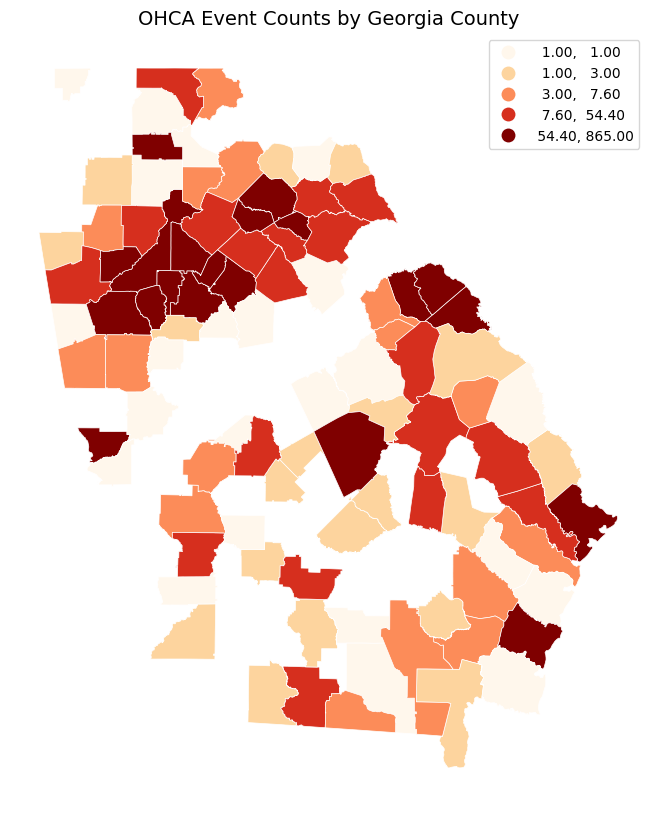

In [14]:
# Plot county OHCA event counts
fig, ax = plt.subplots(figsize=(10, 10))
# Plot county OHCA event counts with a choropleth map.
county_counts.plot(
    column='ohca_event_count',
    cmap='OrRd',
    scheme='quantiles',
    k=5,
    legend=True,
    linewidth=0.5,
    edgecolor='white',
    ax=ax
)
# Set the plot title.
ax.set_title('OHCA Event Counts by Georgia County', fontsize=14)
# Hide map axes for a cleaner display.
ax.axis('off')
# Show the completed plot.
plt.show()

## 9. Create Spatial Weights

Spatial autocorrelation needs a definition of neighboring areas. We start with Queen contiguity, where counties are neighbors if they touch. If there are disconnected polygons, the notebook uses 4-nearest-neighbor weights as a practical fallback.

In [15]:
# Make a separate copy of the county count data and reset the row index.
analysis_gdf = county_counts.reset_index(drop=True).copy()

# Create Queen contiguity weights from the county geometries.
w_queen = Queen.from_dataframe(analysis_gdf, use_index=False)
# Print how many counties have no Queen-contiguous neighbors.
print('Queen islands:', len(w_queen.islands))

# If any county has no Queen-contiguous neighbors, use nearest-neighbor weights instead.
if len(w_queen.islands) > 0:
    # Print a message explaining why KNN weights will be used.
    print('Using KNN weights because some counties have no Queen neighbors in this subset.')
    # Create weights that connect each county to its 4 nearest neighboring counties.
    w = KNN.from_dataframe(analysis_gdf, k=4)
    # Store the name of the spatial weights method used for this analysis.
    weight_method = '4-nearest neighbors'
# If every county has at least one Queen-contiguous neighbor, use the Queen weights.
else:
    # Use the Queen contiguity weights as the spatial weights object.
    w = w_queen
    # Store the name of the spatial weights method used for this analysis.
    weight_method = 'Queen contiguity'

# Row-standardize the spatial weights so each area's neighbor weights sum to 1.
w.transform = 'r'
# Print the spatial weights method selected above.
print('Weight method:', weight_method)
# Print the number of areas included in the spatial weights object.
print('Number of areas:', w.n)

Queen islands: 1
Using KNN weights because some counties have no Queen neighbors in this subset.
Weight method: 4-nearest neighbors
Number of areas: 97


/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
 There is 1 island with id: 53.
  W.__init__(self, neighbors, ids=ids, **kw)


## 10. Global Moran's I

Global Moran's I tests whether high or low OHCA event counts are spatially clustered across the full study area.

- Positive Moran's I: similar values cluster near each other.
- Near zero Moran's I: little spatial pattern.
- Negative Moran's I: neighboring areas tend to be dissimilar.

The p-value tells you whether the observed spatial pattern is statistically significant.
The z-score tells you how far your observed Moran’s I is from what would be expected under randomness.

In [16]:
# Convert the OHCA event count column into a numeric array for Moran's I.
y = analysis_gdf['ohca_event_count'].astype(float).values

# Calculate Global Moran's I using the event counts and spatial weights.
moran = Moran(y, w, permutations=999)

# Print the Global Moran's I statistic.
print(f"Global Moran's I: {moran.I:.4f}")
# Print the simulated p-value from the permutation test.
print(f'Permutation p-value: {moran.p_sim:.4f}')
# Print the simulated z score for the Moran's I result.
print(f'Z score: {moran.z_sim:.4f}')

Global Moran's I: 0.3392
Permutation p-value: 0.0010
Z score: 6.0014


## 10. Global Moran's I

-- Global Moran’s I = 0.3392;
Positive and moderately large, so counties with similar OHCA counts tend to be near each other (spatial clustering).

-- Expected I = -0.0104;
Under spatial randomness, Moran’s I should be around this value (near zero, slightly negative due to sample size/weights structure).

-- Permutation p-value = 0.0010;
Very significant (< 0.05), meaning this pattern is highly unlikely to be random.



## 11. Local Moran's I / LISA Clusters

Local Moran's I identifies where clusters occur. Common labels are:

- High-High: high-count county near high-count neighbors
- Low-Low: low-count county near low-count neighbors
- High-Low: high-count county near low-count neighbors
- Low-High: low-count county near high-count neighbors

In [17]:
# Calculate Local Moran's I for each county using the event counts and spatial weights.
lisa = Moran_Local(y, w, permutations=999)

# Store each county's Local Moran's I statistic in the analysis table.
analysis_gdf['local_moran_i'] = lisa.Is
# Store each county's simulated Local Moran's I p-value in the analysis table.
analysis_gdf['local_moran_p'] = lisa.p_sim
# Store the spatially lagged OHCA event count for each county in the analysis table.
analysis_gdf['spatial_lag_count'] = lag_spatial(w, y)

# Define a helper function that converts a LISA quadrant and p-value into a cluster label.
def lisa_cluster(q, p, alpha=0.05):
    # If the p-value is not below the significance threshold, label the county as not significant.
    if p >= alpha:
        # Return the label for a county without statistically significant local clustering.
        return 'Not significant'
    # Return the cluster label that matches the county's LISA quadrant code.
    return {
        1: 'High-High',
        2: 'Low-High',
        3: 'Low-Low',
        4: 'High-Low'
    }.get(q, 'Not significant')

# Apply the helper function to each county's LISA quadrant and p-value.
analysis_gdf['lisa_cluster'] = [lisa_cluster(q, p) for q, p in zip(lisa.q, lisa.p_sim)]

# Count the number of counties assigned to each LISA cluster label.
analysis_gdf['lisa_cluster'].value_counts()

,count
lisa_cluster,
Not significant,87
High-High,6
Low-High,2
Low-Low,1
High-Low,1


## 12. Map LISA Cluster Results

Saved LISA map PNG: /content/drive/MyDrive/Colab Notebooks/Using-Python-for-Geospatial-Analysis-and-Visualization-main/data/outputs/county_lisa_cluster_map.png


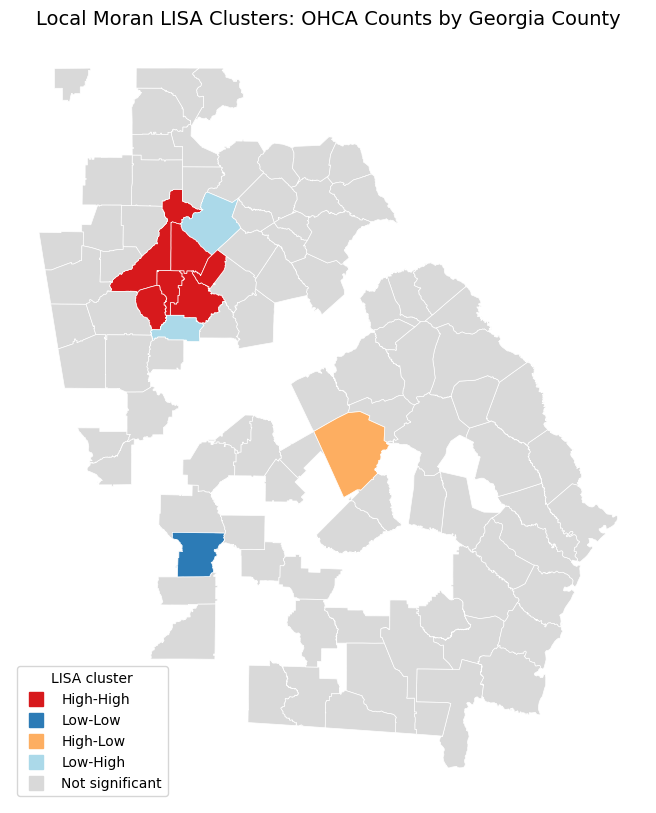

In [18]:
# Match each LISA cluster label to the color that will be used on the map.
cluster_colors = {
    'High-High': '#d7191c',
    'Low-Low': '#2c7bb6',
    'High-Low': '#fdae61',
    'Low-High': '#abd9e9',
    'Not significant': '#d9d9d9'
}

# Create a 10-by-10 inch plotting area for the county map.
fig, ax = plt.subplots(figsize=(10, 10))
# Draw each county polygon using the color assigned to its LISA cluster label.
analysis_gdf.plot(
    color=analysis_gdf['lisa_cluster'].map(cluster_colors),
    linewidth=0.5,
    edgecolor='white',
    ax=ax
)

# Build the legend entries from the LISA cluster color dictionary.
handles = [
    plt.Line2D([0], [0], marker='s', linestyle='', markersize=10, color=color, label=label)
    # Create one square legend marker for this cluster label and color.
    for label, color in cluster_colors.items()
]
# Add the LISA cluster legend to the lower-left corner of the map.
ax.legend(handles=handles, title='LISA cluster', loc='lower left')
# Add a title above the county LISA cluster map.
ax.set_title('Local Moran LISA Clusters: OHCA Counts by Georgia County', fontsize=14)
# Turn off the x- and y-axis lines and labels.
ax.axis('off')

# Set the folder where the map image will be saved.
OUTPUT_DIR = DATA_DIR / 'outputs'
# Create the output folder if it does not already exist.
OUTPUT_DIR.mkdir(exist_ok=True)
# Set the full file path for the saved LISA cluster map PNG.
lisa_png = OUTPUT_DIR / 'county_lisa_cluster_map.png'
# Save the map figure as a high-resolution PNG file.
fig.savefig(lisa_png, dpi=300, bbox_inches='tight')
# Print the path to the saved LISA map PNG file.
print('Saved LISA map PNG:', lisa_png)

# Display the finished LISA cluster map in the notebook.
plt.show()

## 13. Export Results

These outputs can be used for slides, follow-up mapping, or participant exercises.

In [19]:
# Set the folder where the spatial autocorrelation output files will be saved.
OUTPUT_DIR = DATA_DIR / 'outputs'
# Create the output folder if it does not already exist.
OUTPUT_DIR.mkdir(exist_ok=True)

# Set the full file path for the CSV output file.
csv_out = OUTPUT_DIR / 'county_ohca_spatial_autocorrelation_results.csv'
# Set the full file path for the GeoJSON output file.
geojson_out = OUTPUT_DIR / 'county_ohca_spatial_autocorrelation_results.geojson'

# Save the analysis table without the geometry column as a CSV file.
analysis_gdf.drop(columns='geometry').to_csv(csv_out, index=False)
# Save the full analysis GeoDataFrame, including geometry, as a GeoJSON file.
analysis_gdf.to_file(geojson_out, driver='GeoJSON')

# Print the path to the saved CSV file.
print('Saved CSV:', csv_out)
# Print the path to the saved GeoJSON file.
print('Saved GeoJSON:', geojson_out)

Saved CSV: /content/drive/MyDrive/Colab Notebooks/Using-Python-for-Geospatial-Analysis-and-Visualization-main/data/outputs/county_ohca_spatial_autocorrelation_results.csv
Saved GeoJSON: /content/drive/MyDrive/Colab Notebooks/Using-Python-for-Geospatial-Analysis-and-Visualization-main/data/outputs/county_ohca_spatial_autocorrelation_results.geojson


## Discussion Questions

1. What does a significant Global Moran's I tell us about OHCA event counts?
2. Where are High-High clusters located, and how might public health researchers interpret them?
3. Why might raw counts be misleading compared with population-adjusted rates?
4. How would the results change if we used census tracts instead of counties?